## Binance training for XGBoost model

In [1]:
import pandas as pd
import numpy as np
import random

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor

random.seed(42)
np.random.seed(42)

In [2]:
bnb_df_xgb = pd.read_csv(r'feature_datasets\BNB_features.csv', parse_dates=True, index_col=0)

print(bnb_df_xgb.shape)
bnb_df_xgb.head()

(916, 30)


,Close,High,Low,Open,Volume,Daily_Return,Close_Lag_1,Close_Lag_7,Close_Lag_14,Close_Lag_30,...,HL_Spread,Volume_MA_7,Volume_MA_21,Volume_MA_60,Volume_MA_180,Volume_Change,Target_Return_7,Target_Return_30,Target_Return_365,Target_Up
Date,,,,,,,,,,,,,,,,,,,,,
2021-06-30,303.295868,304.801361,281.778015,300.958801,1.903538e+09,0.010274,300.211548,294.490295,347.033447,354.329346,...,23.023346,1.951054e+09,2.140813e+09,3.700135e+09,3.638568e+09,-0.022035,0.079878,0.064668,-0.276943,1
2021-07-01,288.218414,303.527374,281.579132,303.527374,1.357795e+09,-0.049712,303.295868,308.397034,352.738525,362.794647,...,21.948242,1.813078e+09,2.086183e+09,3.660011e+09,3.643211e+09,-0.286700,0.077055,0.157281,-0.250515,1
2021-07-02,287.423096,290.621674,277.350311,287.754456,1.133633e+09,-0.002759,288.218414,281.620911,336.809692,401.262329,...,13.271362,1.643887e+09,2.032074e+09,3.590991e+09,3.645298e+09,-0.165093,0.101110,0.160255,-0.241414,1
2021-07-03,298.237122,302.605865,283.434021,287.215607,1.113777e+09,0.037624,287.423096,279.438049,335.712830,427.807922,...,19.171844,1.528448e+09,1.982885e+09,3.514084e+09,3.646997e+09,-0.017515,0.060029,0.110201,-0.265751,1
2021-07-04,307.732086,314.713013,292.787384,298.113556,1.387396e+09,0.031837,298.237122,290.567017,340.067200,391.395325,...,21.925629,1.509307e+09,1.945528e+09,3.466400e+09,3.651126e+09,0.245667,0.046468,0.048795,-0.247481,1


In [3]:
# Target = next-day Close
bnb_y_xgb = bnb_df_xgb['Close'].shift(-1)

# Features = all columns except Close
bnb_X_xgb = bnb_df_xgb.drop(columns=['Close'])

# Drop last row because shifted target becomes NaN
bnb_X_xgb = bnb_X_xgb.iloc[:-1]
bnb_y_xgb = bnb_y_xgb.iloc[:-1]

print("BNB X shape:", bnb_X_xgb.shape)
print("BNB y shape:", bnb_y_xgb.shape)

BNB X shape: (915, 29)
BNB y shape: (915,)


In [4]:
split_idx = int(len(bnb_X_xgb) * 0.7)

bnb_X_train_xgb = bnb_X_xgb.iloc[:split_idx]
bnb_X_test_xgb = bnb_X_xgb.iloc[split_idx:]

bnb_y_train_xgb = bnb_y_xgb.iloc[:split_idx]
bnb_y_test_xgb = bnb_y_xgb.iloc[split_idx:]

print("X_train shape:", bnb_X_train_xgb.shape)
print("X_test shape:", bnb_X_test_xgb.shape)
print("y_train shape:", bnb_y_train_xgb.shape)
print("y_test shape:", bnb_y_test_xgb.shape)

X_train shape: (640, 29)
X_test shape: (275, 29)
y_train shape: (640,)
y_test shape: (275,)


In [ ]:
model_xgb = XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42
)

model_xgb.fit(bnb_X_train_xgb, bnb_y_train_xgb)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [6]:
bnb_preds_xgb = model_xgb.predict(bnb_X_test_xgb)

print("Predictions shape:", bnb_preds_xgb.shape)
print("First 10 predictions:", bnb_preds_xgb[:10])

Predictions shape: (275,)
First 10 predictions: [317.4713  317.1384  304.98755 315.38107 316.56537 316.94302 316.82965
 318.8002  320.38507 315.87997]


In [8]:
mse_xgb = mean_squared_error(bnb_y_test_xgb, bnb_preds_xgb)
rmse_xgb = np.sqrt(mse_xgb)
mae_xgb = mean_absolute_error(bnb_y_test_xgb, bnb_preds_xgb)
r2_xgb = r2_score(bnb_y_test_xgb, bnb_preds_xgb)
mape_xgb = np.mean(np.abs((bnb_y_test_xgb - bnb_preds_xgb) / bnb_y_test_xgb)) * 100

print("XGBoost Results:")
print(f"MSE: {mse_xgb:.2f}")
print(f"RMSE: {rmse_xgb:.2f}")
print(f"MAE: {mae_xgb:.2f}")
print(f"R2 Score: {r2_xgb:.4f}")
print(f"MAPE: {mape_xgb:.2f}%")

XGBoost Results:
MSE: 1593.23
RMSE: 39.92
MAE: 33.21
R2 Score: 0.0100
MAPE: 14.48%


In [9]:
results_xgb = pd.DataFrame({
    "Actual": bnb_y_test_xgb.values,
    "Predicted": bnb_preds_xgb
})

results_xgb.head()

,Actual,Predicted
0,313.928619,317.471313
1,308.562378,317.138397
2,310.994843,304.987549
3,314.063171,315.381073
4,312.454651,316.565369


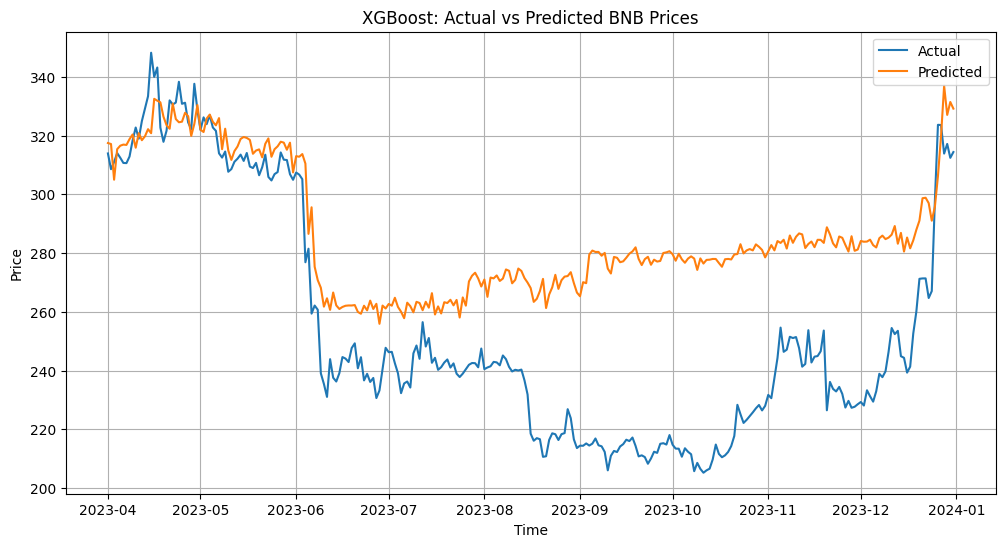

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(bnb_y_test_xgb.index,bnb_y_test_xgb.values, label="Actual")
plt.plot(bnb_y_test_xgb.index,bnb_preds_xgb, label="Predicted")
plt.title("XGBoost: Actual vs Predicted BNB Prices")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()

              Feature  Importance
1                 Low    0.514358
0                High    0.337929
2                Open    0.034679
11               MA_7    0.030728
27  Target_Return_365    0.014853
5         Close_Lag_1    0.011126
20        Volume_MA_7    0.007177
14             MA_180    0.007141
13              MA_60    0.003328
10      Close_Lag_180    0.003230


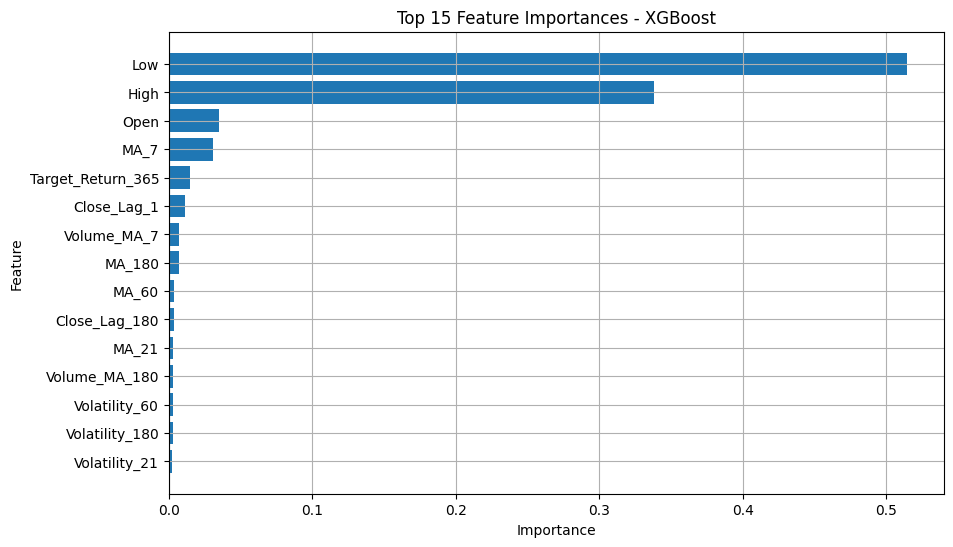

In [13]:
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    "Feature": bnb_X_train_xgb.columns,
    "Importance": model_xgb.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(importance.head(10))

plt.figure(figsize=(10, 6))
plt.barh(importance["Feature"].head(15)[::-1], importance["Importance"].head(15)[::-1])
plt.title("Top 15 Feature Importances - XGBoost")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.grid(True)
plt.show()

## Finetuning Xgboost model

In [14]:
import optuna
import numpy as np
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error

def objective(trial):
    n_estimators = trial.suggest_int("n_estimators", 100, 500)
    max_depth = trial.suggest_int("max_depth", 3, 10)
    learning_rate = trial.suggest_float("learning_rate", 1e-3, 0.3, log=True)
    subsample = trial.suggest_float("subsample", 0.6, 1.0)
    colsample_bytree = trial.suggest_float("colsample_bytree", 0.6, 1.0)

    model_xgb_opt = XGBRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        learning_rate=learning_rate,
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        objective="reg:squarederror",
        random_state=42
    )

    model_xgb_opt.fit(bnb_X_train_xgb, bnb_y_train_xgb)

    preds_xgb_opt = model_xgb_opt.predict(bnb_X_test_xgb)

    rmse_xgb_opt = np.sqrt(mean_squared_error(bnb_y_test_xgb, preds_xgb_opt))
    return rmse_xgb_opt

c:\Users\tharu\anaconda3\envs\Streamlit\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [15]:
study_xgb = optuna.create_study(
    direction="minimize",
    study_name="xgb_optuna_bnb",
    storage="sqlite:///xgb_optuna_bnb.db",
    load_if_exists=True
)

study_xgb.optimize(objective, n_trials=50)

[I 2026-04-11 12:26:16,626] A new study created in RDB with name: xgb_optuna_bnb
[I 2026-04-11 12:26:19,142] Trial 0 finished with value: 38.840401888400066 and parameters: {'n_estimators': 416, 'max_depth': 6, 'learning_rate': 0.022226639448216474, 'subsample': 0.8406056169123294, 'colsample_bytree': 0.8952141343870751}. Best is trial 0 with value: 38.840401888400066.
[I 2026-04-11 12:26:20,591] Trial 1 finished with value: 63.13303789714706 and parameters: {'n_estimators': 308, 'max_depth': 6, 'learning_rate': 0.0029274841280567017, 'subsample': 0.7663617520778343, 'colsample_bytree': 0.7334479941584839}. Best is trial 0 with value: 38.840401888400066.
[I 2026-04-11 12:26:21,646] Trial 2 finished with value: 24.08311242365045 and parameters: {'n_estimators': 427, 'max_depth': 3, 'learning_rate': 0.07330505812951534, 'subsample': 0.7802691815432206, 'colsample_bytree': 0.8333305030649314}. Best is trial 2 with value: 24.08311242365045.
[I 2026-04-11 12:26:23,571] Trial 3 finished with

In [16]:
print("Best XGBoost RMSE:", study_xgb.best_value)
print("Best XGBoost Parameters:", study_xgb.best_params)

Best XGBoost RMSE: 14.146404072698973
Best XGBoost Parameters: {'n_estimators': 423, 'max_depth': 3, 'learning_rate': 0.01820539910599997, 'subsample': 0.7627246145831678, 'colsample_bytree': 0.6012820583255524}


In [17]:
best_params_xgb = study_xgb.best_params

model_xgb_best = XGBRegressor(
    n_estimators=best_params_xgb["n_estimators"],
    max_depth=best_params_xgb["max_depth"],
    learning_rate=best_params_xgb["learning_rate"],
    subsample=best_params_xgb["subsample"],
    colsample_bytree=best_params_xgb["colsample_bytree"],
    objective="reg:squarederror",
    random_state=42
)

model_xgb_best.fit(bnb_X_train_xgb, bnb_y_train_xgb)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.6012820583255524
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import

In [18]:
bnb_preds_xgb_best = model_xgb_best.predict(bnb_X_test_xgb)

print("Predictions shape:", bnb_preds_xgb_best.shape)
print("First 10 predictions:", bnb_preds_xgb_best[:10])

Predictions shape: (275,)
First 10 predictions: [315.2203  314.93332 306.4773  313.21307 316.59265 315.38058 315.04886
 315.27243 316.33026 318.50778]


In [19]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

mse_xgb_best = mean_squared_error(bnb_y_test_xgb, bnb_preds_xgb_best)
rmse_xgb_best = np.sqrt(mse_xgb_best)
mae_xgb_best = mean_absolute_error(bnb_y_test_xgb, bnb_preds_xgb_best)
r2_xgb_best = r2_score(bnb_y_test_xgb, bnb_preds_xgb_best)
mape_xgb_best = np.mean(np.abs((bnb_y_test_xgb - bnb_preds_xgb_best) / bnb_y_test_xgb)) * 100

print("Best XGBoost Results:")
print(f"MSE: {mse_xgb_best:.2f}")
print(f"RMSE: {rmse_xgb_best:.2f}")
print(f"MAE: {mae_xgb_best:.2f}")
print(f"R2 Score: {r2_xgb_best:.4f}")
print(f"MAPE: {mape_xgb_best:.2f}%")

Best XGBoost Results:
MSE: 200.12
RMSE: 14.15
MAE: 11.13
R2 Score: 0.8757
MAPE: 4.81%
